In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from scipy.stats import boxcox
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

%matplotlib inline



In [7]:
# Set the resolution of the plotted figures
plt.rcParams['figure.dpi'] = 200

# Configure Seaborn plot styles: Set background color and use dark grid
sns.set(rc={'axes.facecolor': '#faded9'}, style='darkgrid')

In [9]:
# Read dataset
df = pd.read_csv('heart.csv')

# Display first 5 rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [10]:
# Display a concise summary of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [11]:
# Define the continuous features
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Identify the features to be converted to object data type
features_to_convert = [feature for feature in df.columns if feature not in continuous_features]

# Convert the identified features to object data type
df[features_to_convert] = df[features_to_convert].astype('object')

# Check data types
df.dtypes

,0
age,int64
sex,object
cp,object
trestbps,int64
chol,int64
fbs,object
restecg,object
thalach,int64
exang,object
oldpeak,float64


In [12]:
# Get the summary statistics for categorical variables
df.describe(include='object')

,sex,cp,fbs,restecg,exang,slope,ca,thal,target
count,1025,1025,1025,1025,1025,1025,1025,1025,1025
unique,2,4,2,3,2,3,5,4,2
top,1,0,0,1,0,1,0,2,1
freq,713,497,872,513,680,482,578,544,526


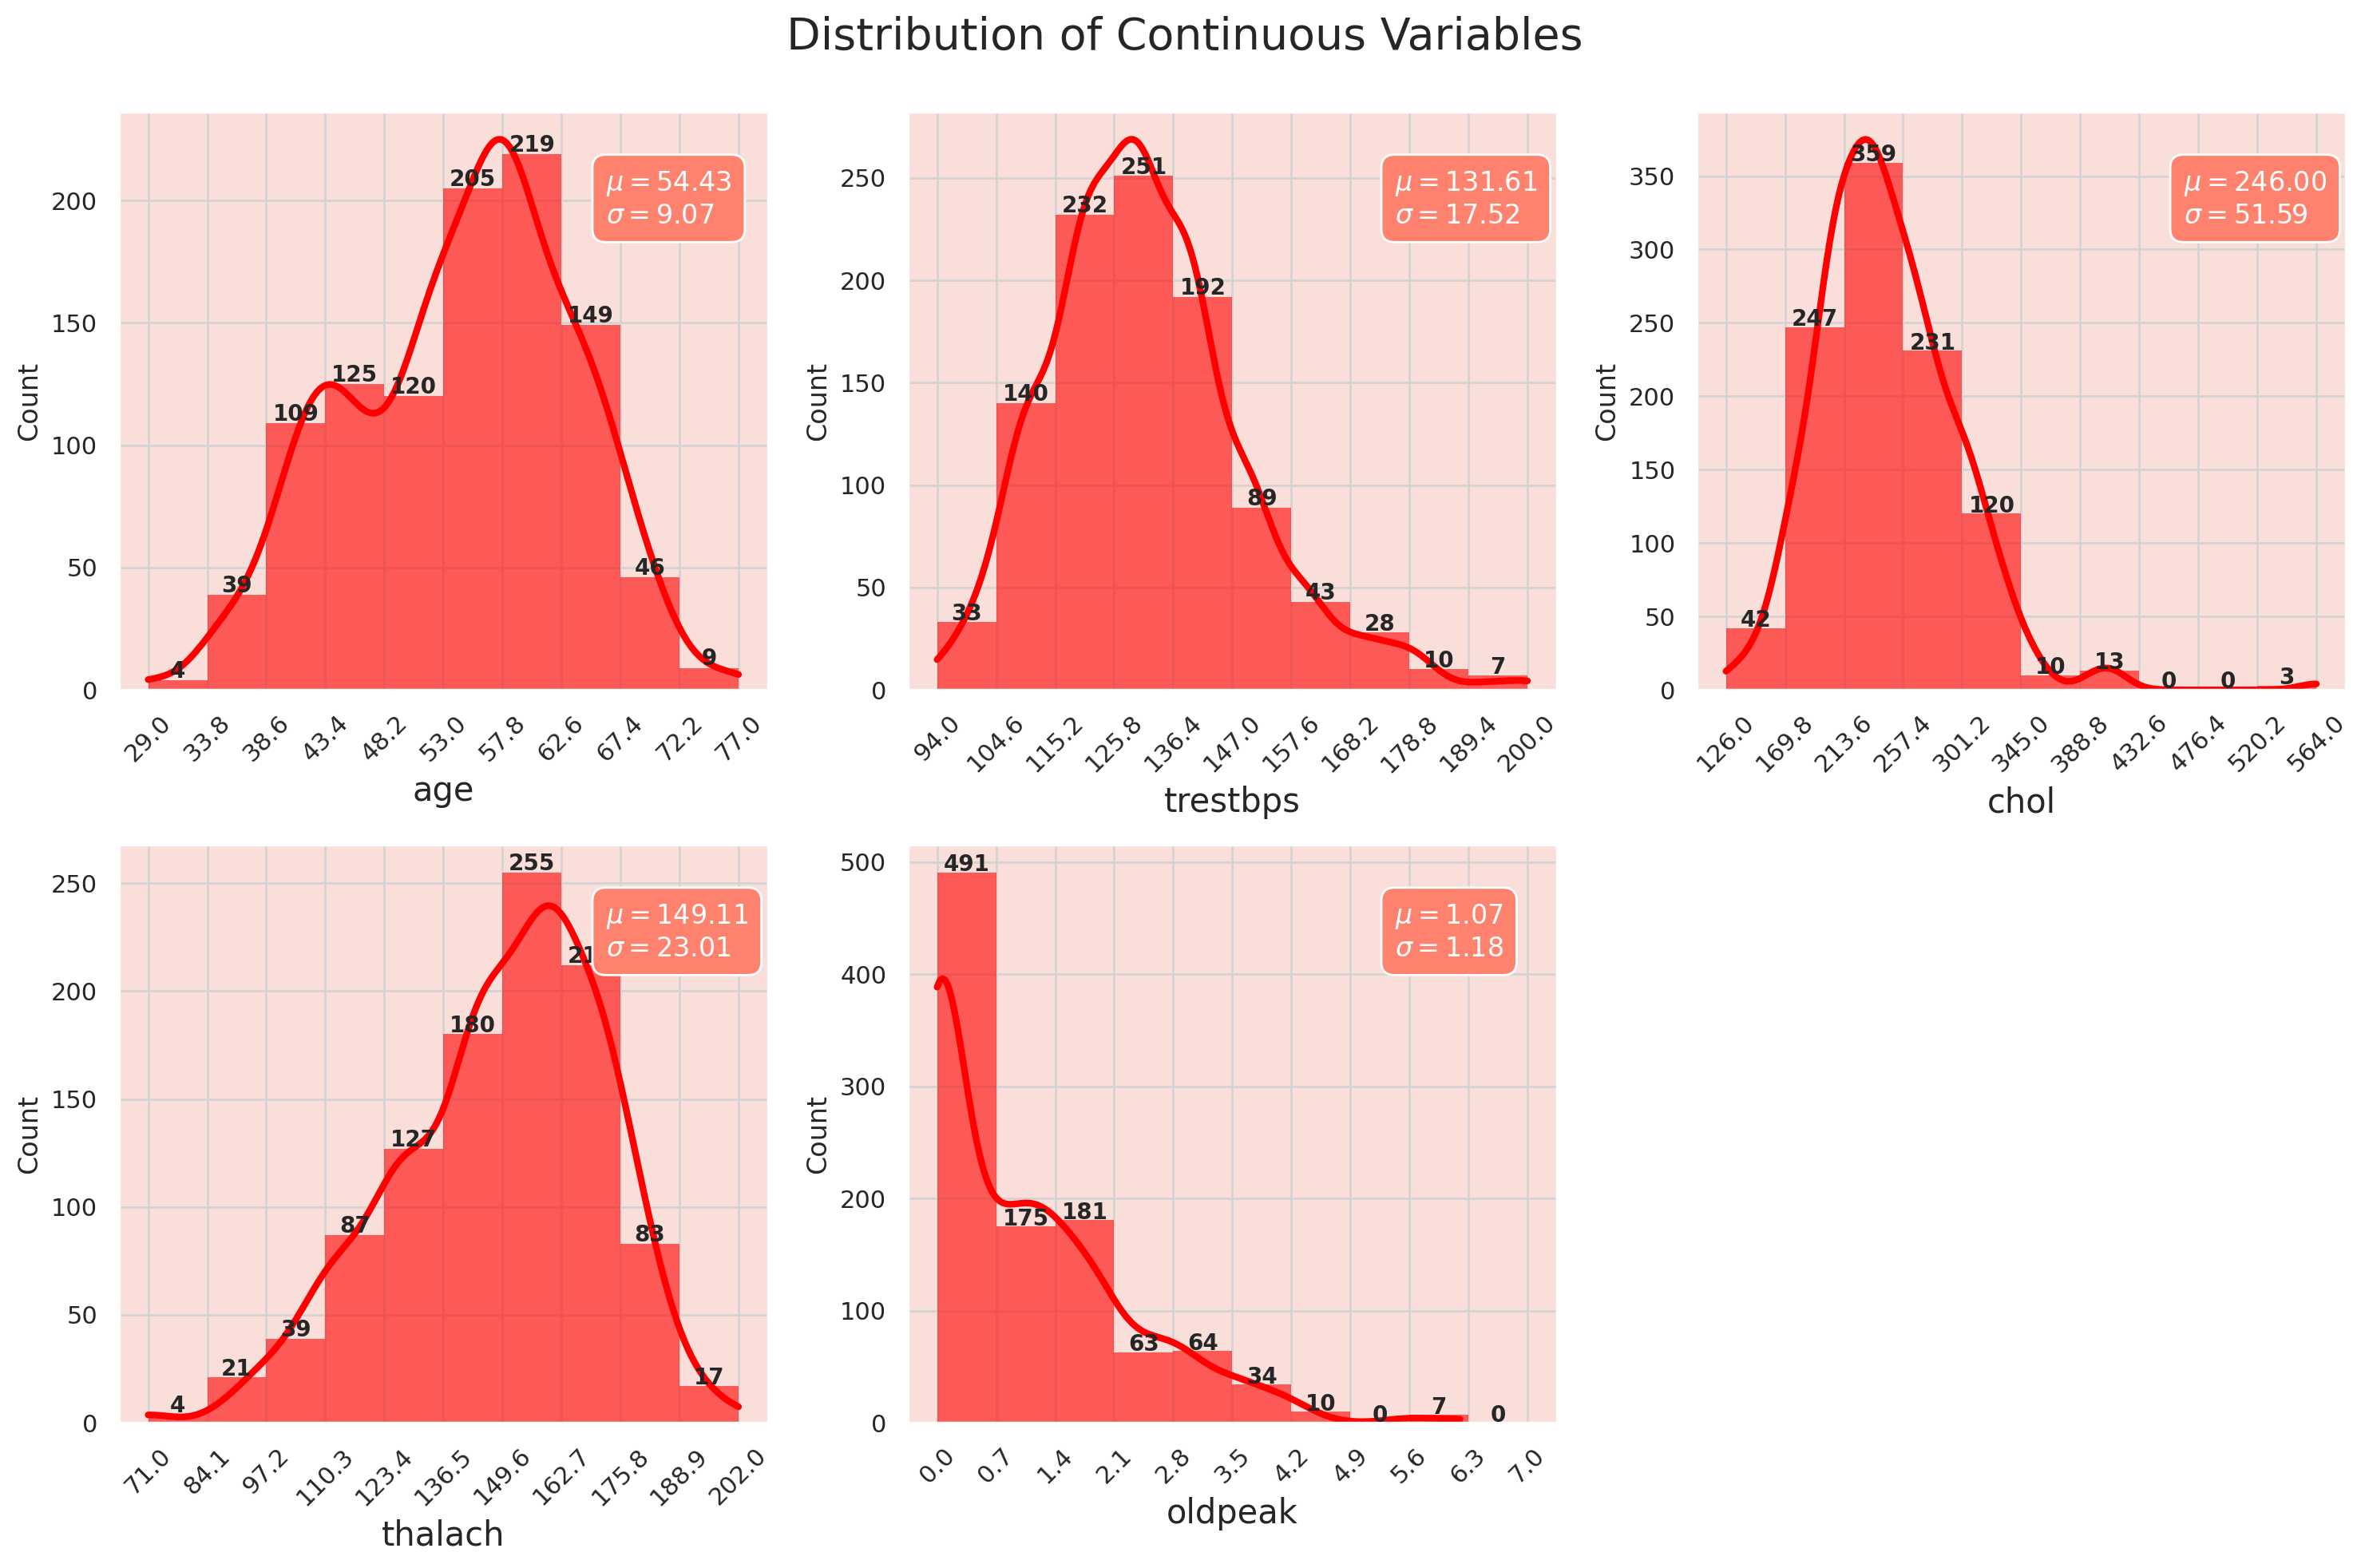

In [13]:
# Filter out continuous features for the univariate analysis
df_continuous = df[continuous_features]

# Set up the subplot
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

# Loop to plot histograms for each continuous feature
for i, col in enumerate(df_continuous.columns):
    x = i // 3
    y = i % 3

    values, bin_edges = np.histogram(
        df_continuous[col],
        range=(np.floor(df_continuous[col].min()), np.ceil(df_continuous[col].max()))
    )

    graph = sns.histplot(
        data=df_continuous,
        x=col,
        bins=bin_edges,
        kde=True,
        ax=ax[x, y],
        edgecolor='none',
        color='red',
        alpha=0.6,
        line_kws={'lw': 3}
    )

    ax[x, y].set_xlabel(col, fontsize=15)
    ax[x, y].set_ylabel('Count', fontsize=12)
    ax[x, y].set_xticks(np.round(bin_edges, 1))
    ax[x, y].set_xticklabels(ax[x, y].get_xticks(), rotation=45)
    ax[x, y].grid(color='lightgrey')

    # Annotate bars
    for j, p in enumerate(graph.patches):
        ax[x, y].annotate(
            '{}'.format(p.get_height()),
            (p.get_x() + p.get_width() / 2, p.get_height() + 1),
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

    # Add mean and std text
    textstr = '\n'.join((
        r'$\mu=%.2f$' % df_continuous[col].mean(),
        r'$\sigma=%.2f$' % df_continuous[col].std()
    ))

    ax[x, y].text(
        0.75, 0.9, textstr,
        transform=ax[x, y].transAxes,
        fontsize=12,
        verticalalignment='top',
        color='white',
        bbox=dict(boxstyle='round', facecolor='#ff826e', edgecolor='white', pad=0.5)
    )

# Remove empty subplot
ax[1, 2].axis('off')

# Title and layout
plt.suptitle('Distribution of Continuous Variables', fontsize=20)
plt.tight_layout()
plt.subplots_adjust(top=0.92)

plt.show()

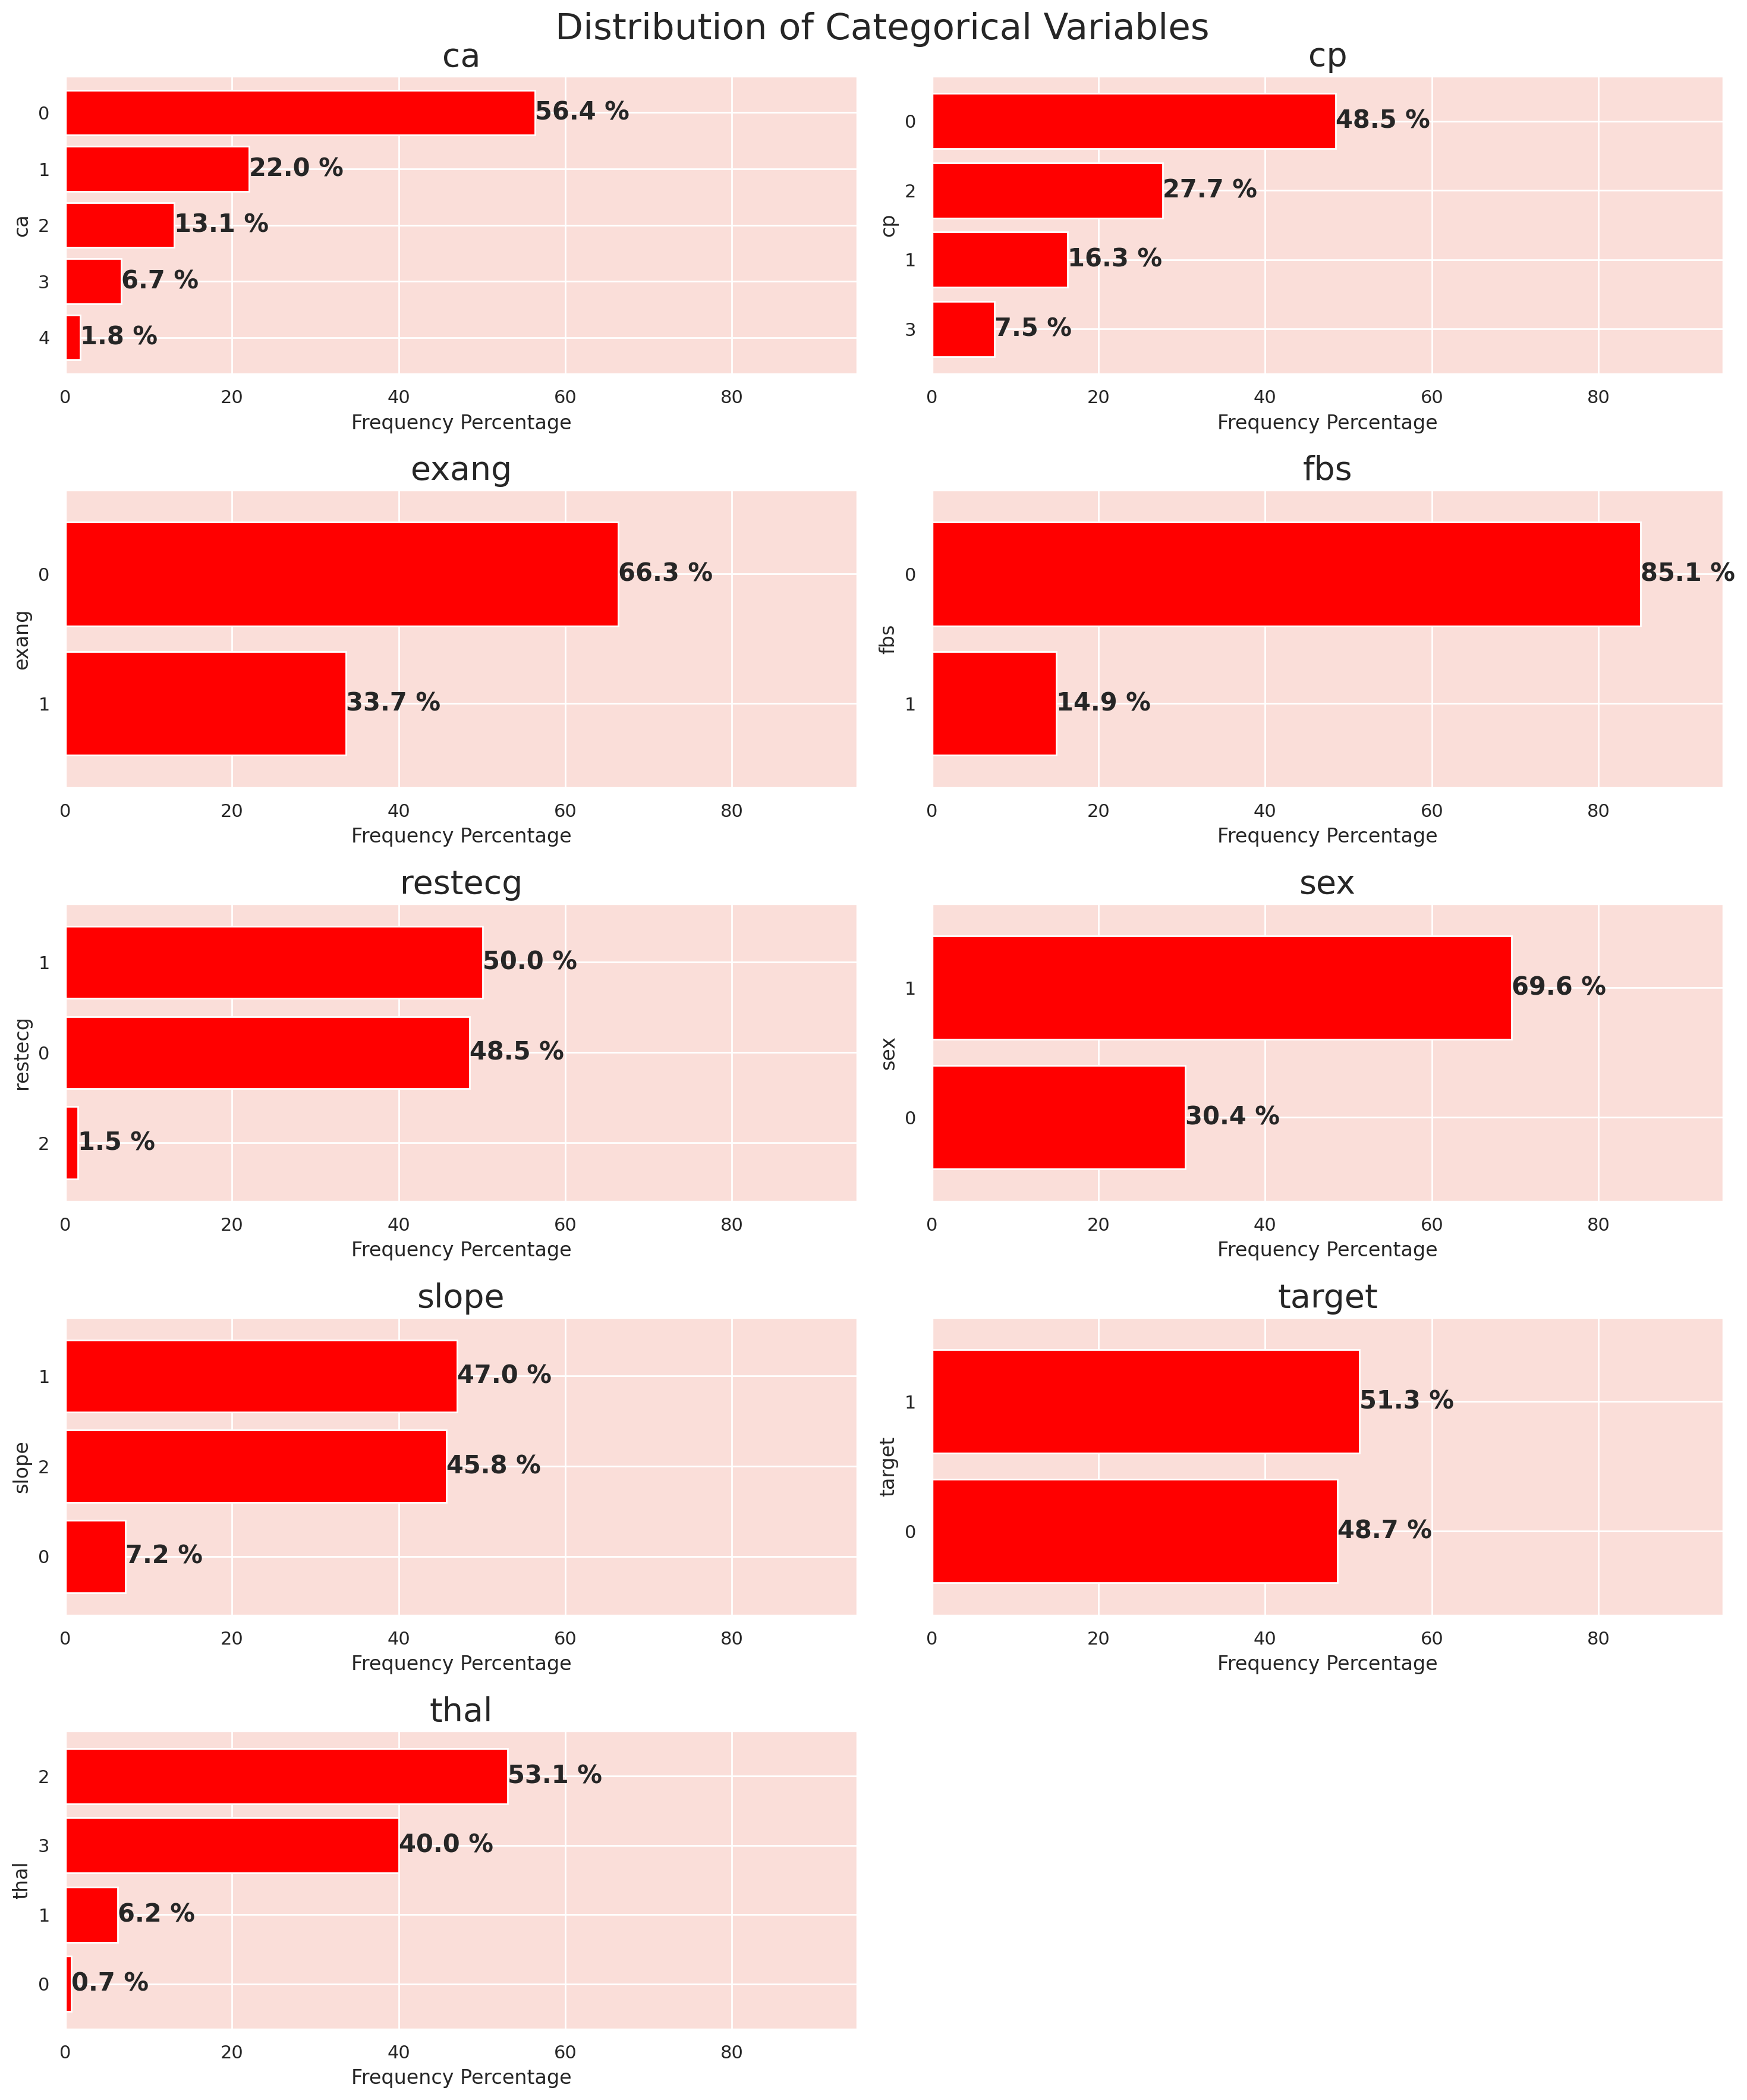

In [14]:
# Filter out categorical features for the univariate analysis
categorical_features = df.columns.difference(continuous_features)
df_categorical = df[categorical_features]

# Set up the subplot for a 5x2 layout
fig, ax = plt.subplots(nrows=5, ncols=2, figsize=(15, 18))

# Loop to plot bar charts for each categorical feature
for i, col in enumerate(categorical_features):
    row = i // 2
    col_idx = i % 2

    # Calculate frequency percentages
    value_counts = df[col].value_counts(normalize=True).mul(100).sort_values()

    # Plot bar chart
    value_counts.plot(kind='barh', ax=ax[row, col_idx], width=0.8, color='red')

    # Add frequency percentages to the bars
    for index, value in enumerate(value_counts):
        ax[row, col_idx].text(
            value,
            index,
            str(round(value, 1)) + ' %',
            fontsize=15,
            weight='bold',
            va='center'
        )

    ax[row, col_idx].set_xlim([0, 95])
    ax[row, col_idx].set_xlabel('Frequency Percentage', fontsize=12)
    ax[row, col_idx].set_title(f'{col}', fontsize=20)

# Remove empty subplot
ax[4, 1].axis('off')

# Title and layout
plt.suptitle('Distribution of Categorical Variables', fontsize=22)
plt.tight_layout()
plt.subplots_adjust(top=0.95)

plt.show()

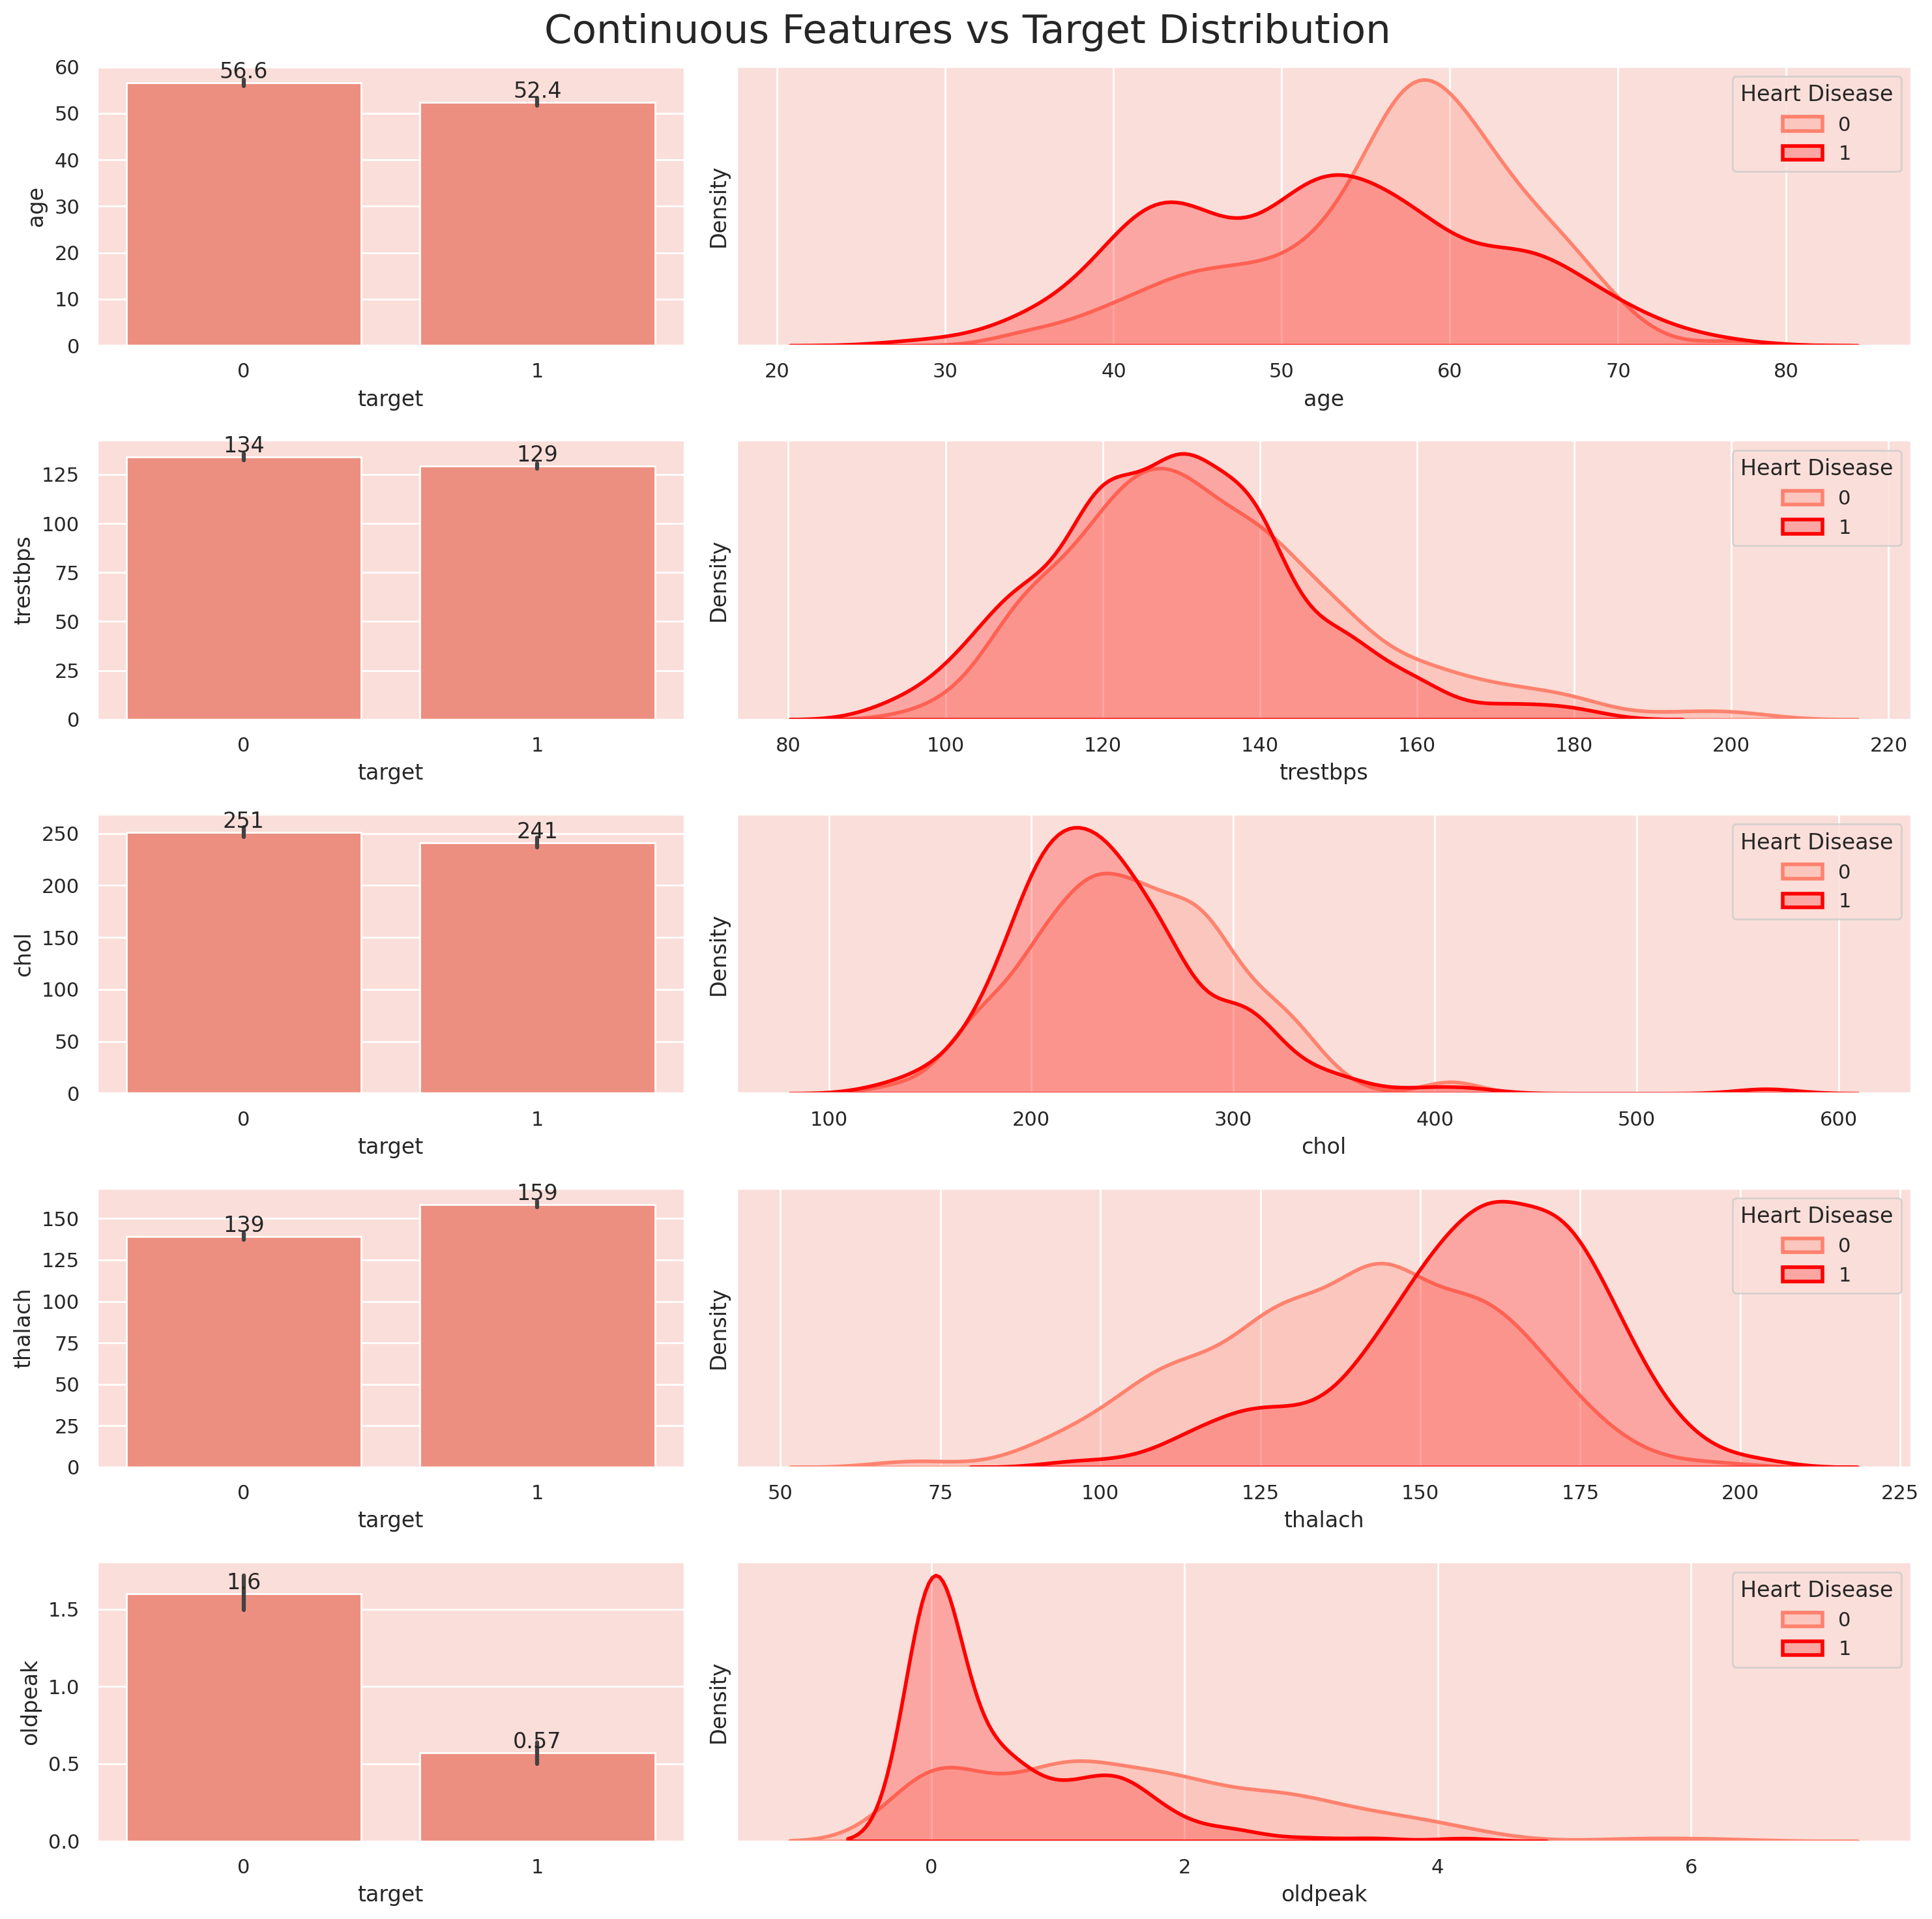

In [15]:
# Set color palette
sns.set_palette(['#ff826e', 'red'])

# Create the subplots
fig, ax = plt.subplots(len(continuous_features), 2, figsize=(15, 15),
                       gridspec_kw={'width_ratios': [1, 2]})

# Loop through each continuous feature to create barplots and KDE plots
for i, col in enumerate(continuous_features):

    # Barplot showing the mean value of the feature for each target category
    graph = sns.barplot(data=df, x="target", y=col, ax=ax[i, 0])

    # KDE plot showing the distribution of the feature for each target category
    sns.kdeplot(data=df[df["target"] == 0], x=col, fill=True, linewidth=2, ax=ax[i, 1], label='0')
    sns.kdeplot(data=df[df["target"] == 1], x=col, fill=True, linewidth=2, ax=ax[i, 1], label='1')

    ax[i, 1].set_yticks([])
    ax[i, 1].legend(title='Heart Disease', loc='upper right')

    # Add mean values to the barplot
    for cont in graph.containers:
        graph.bar_label(cont, fmt='%.3g')

# Set the title for the entire figure
plt.suptitle('Continuous Features vs Target Distribution', fontsize=22)
plt.tight_layout()

plt.show()

In [16]:
# Check for missing values in the dataset
df.isnull().sum().sum()

np.int64(0)

In [17]:
# Define continuous features (already created earlier)
continuous_features

# Calculate Q1 and Q3
Q1 = df[continuous_features].quantile(0.25)
Q3 = df[continuous_features].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Count outliers using IQR method
outliers_count_specified = (
    ((df[continuous_features] < (Q1 - 1.5 * IQR)) |
     (df[continuous_features] > (Q3 + 1.5 * IQR)))
).sum()

# Display outlier counts
outliers_count_specified

,0
age,0
trestbps,30
chol,16
thalach,4
oldpeak,7


In [18]:
# Implementing one-hot encoding on the specified categorical features
df_encoded = pd.get_dummies(df, columns=['cp', 'restecg', 'thal'], drop_first=True)

# Convert the rest of the categorical variables that don't need one-hot encoding to integer data type
features_to_convert = ['sex', 'fbs', 'exang', 'slope', 'ca', 'target']

for feature in features_to_convert:
    df_encoded[feature] = df_encoded[feature].astype(int)

# Check data types
df_encoded.dtypes

,0
age,int64
sex,int64
trestbps,int64
chol,int64
fbs,int64
thalach,int64
exang,int64
oldpeak,float64
slope,int64
ca,int64


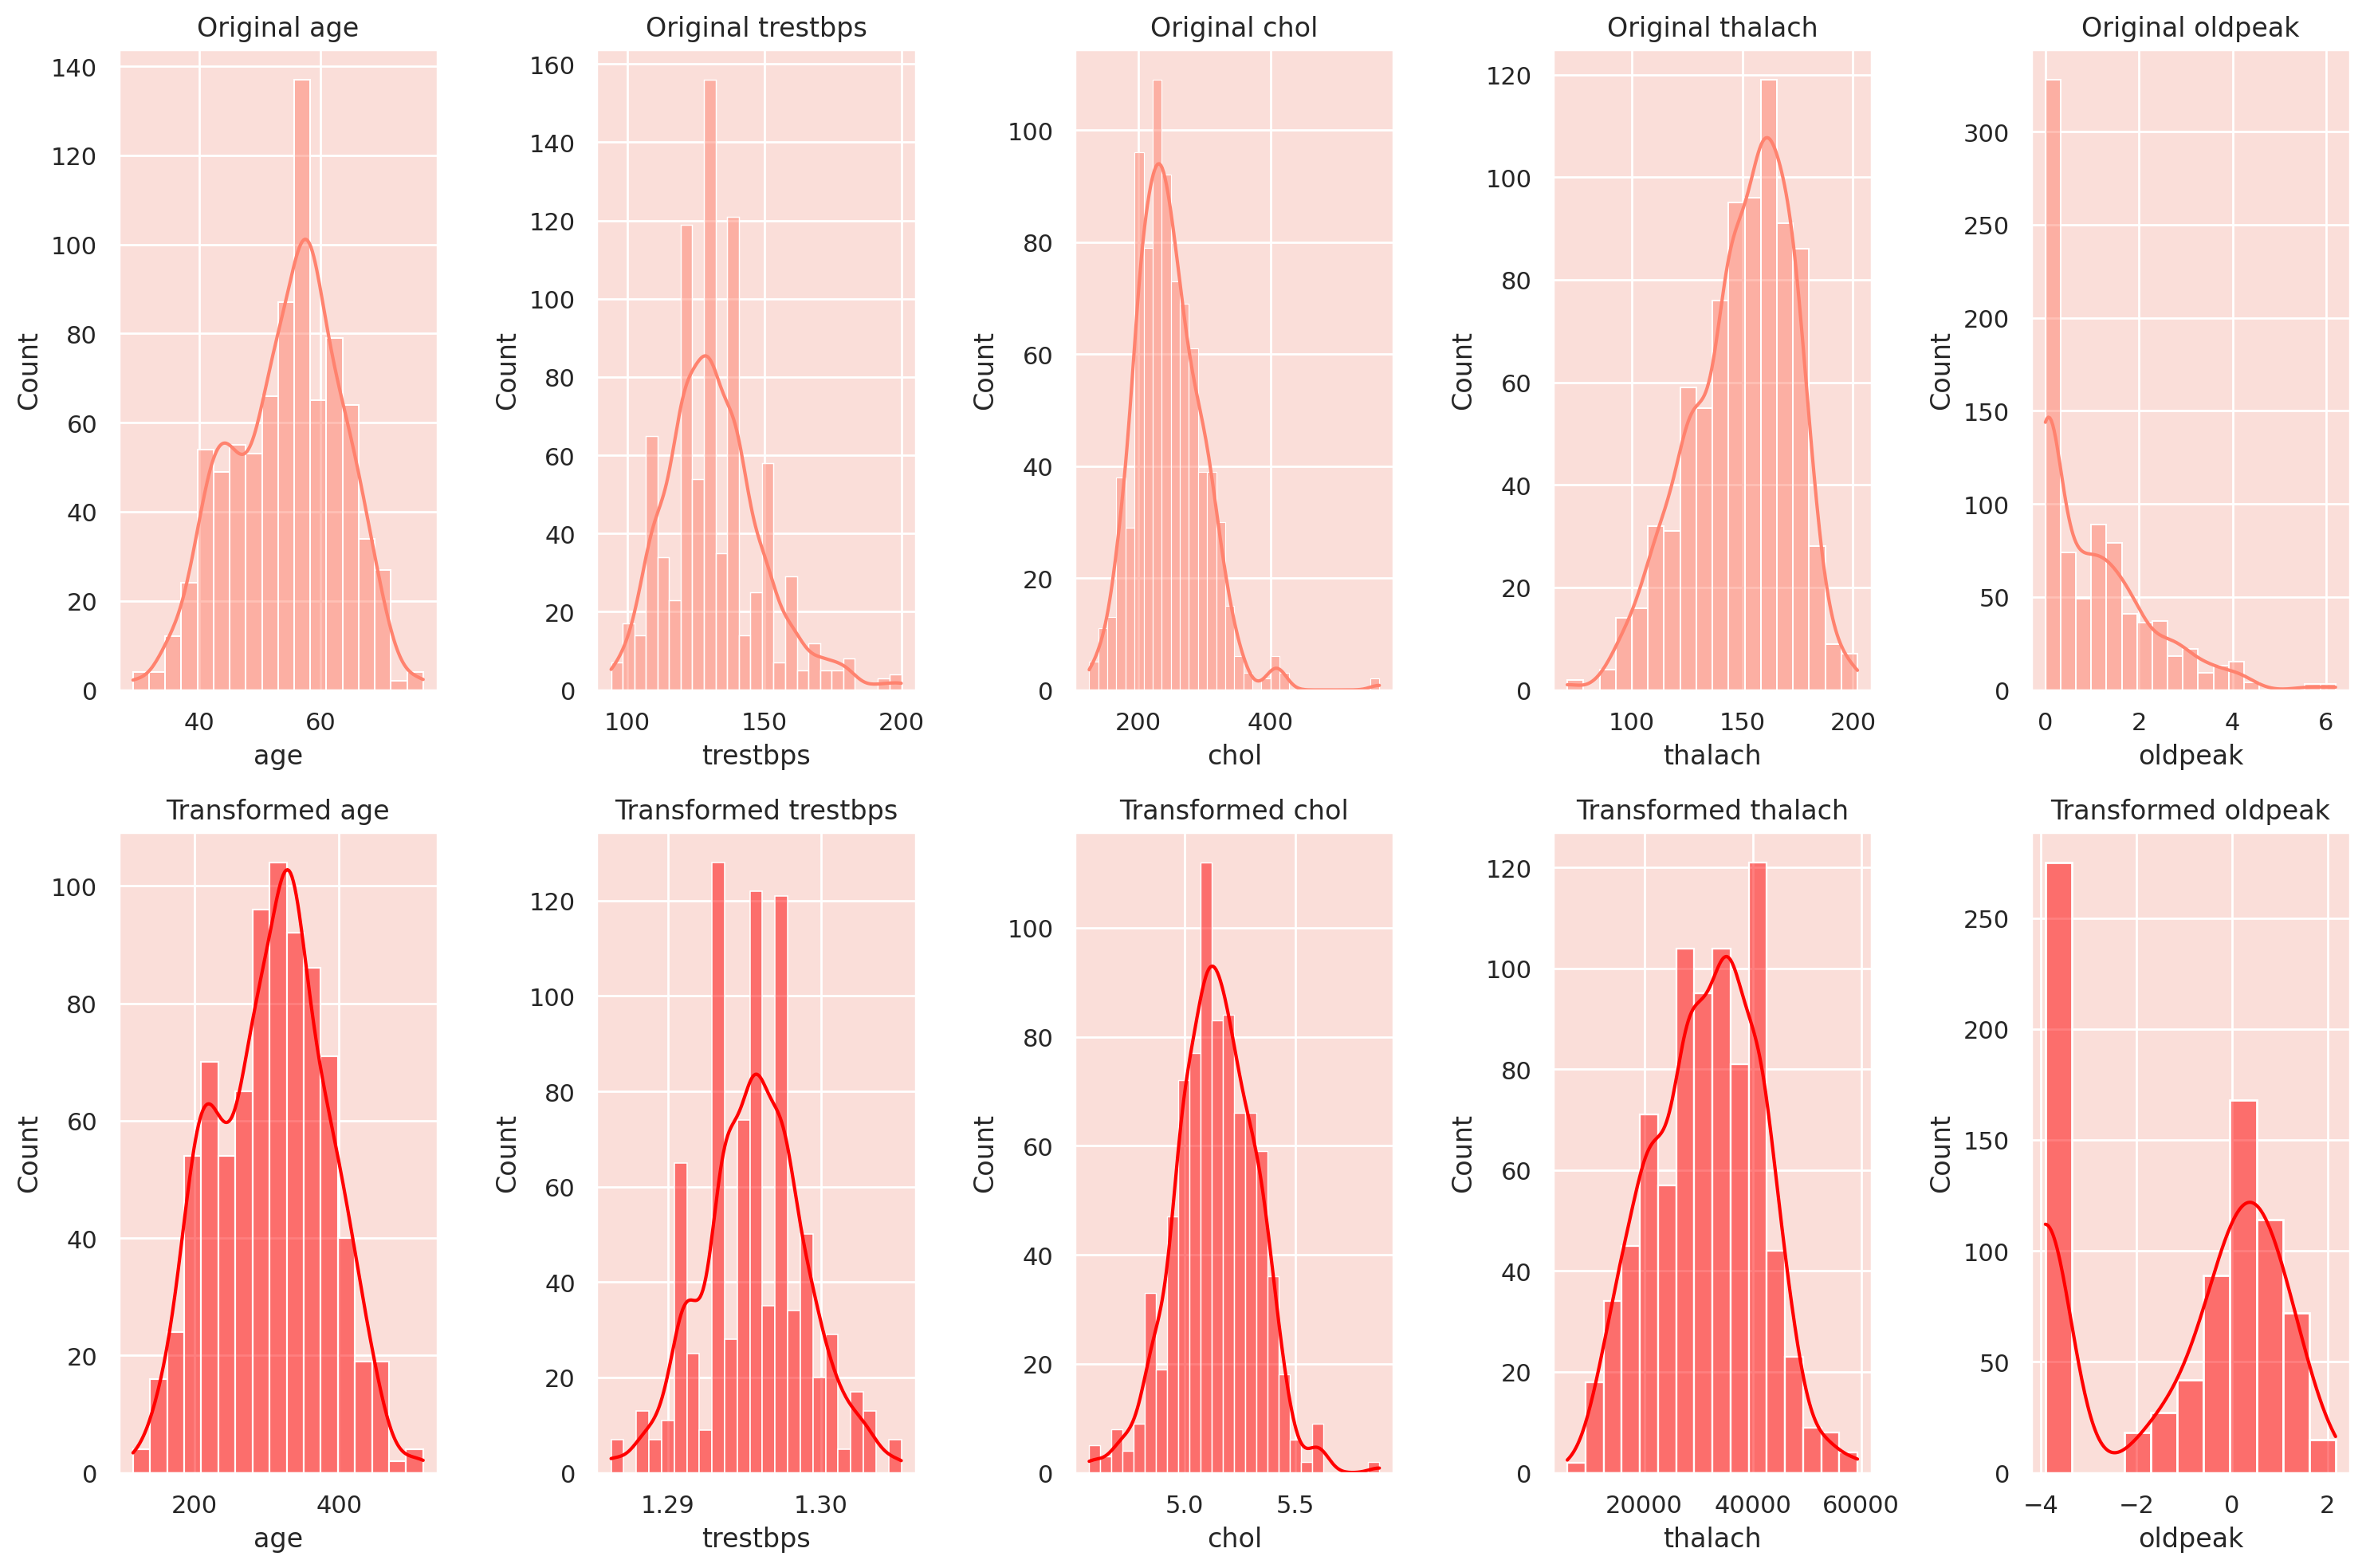

In [19]:
# Define the features (X) and the output labels (y)
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# Splitting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# Check shapes
X_train.shape, X_test.shape


# Adding a small constant to 'oldpeak' to make all values positive
X_train['oldpeak'] = X_train['oldpeak'] + 0.001
X_test['oldpeak'] = X_test['oldpeak'] + 0.001


# Checking the distribution of the continuous features
fig, ax = plt.subplots(2, 5, figsize=(15, 10))

# Original Distributions
for i, col in enumerate(continuous_features):
    sns.histplot(X_train[col], kde=True, ax=ax[0, i], color='#ff826e')
    ax[0, i].set_title(f'Original {col}')


# Applying Box-Cox Transformation
# Dictionary to store lambda values for each feature
lambdas = {}

for i, col in enumerate(continuous_features):
    # Only apply box-cox for positive values
    if X_train[col].min() > 0:
        X_train[col], lambdas[col] = boxcox(X_train[col])

        # Apply same lambda to test data
        X_test[col] = boxcox(X_test[col], lmbda=lambdas[col])

        sns.histplot(X_train[col], kde=True, ax=ax[1, i], color='red')
        ax[1, i].set_title(f'Transformed {col}')
    else:
        sns.histplot(X_train[col], kde=True, ax=ax[1, i], color='green')
        ax[1, i].set_title(f'Not Transformed {col}')

fig.tight_layout()
plt.show()

In [20]:
X_train.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
397,188.243856,1,1.291178,4.818108,0,16654.592901,1,0.739965,1,0,False,False,False,False,False,False,False,True
687,333.780047,1,1.294735,5.333013,0,40983.789741,0,-3.905686,2,2,False,False,False,False,False,False,False,True
909,265.549657,1,1.298293,4.977378,0,20800.169014,1,-0.103254,1,0,False,False,False,False,False,False,False,True
153,298.985470,1,1.293636,5.201127,0,29291.926122,0,-0.840949,1,0,False,True,False,False,False,False,False,True
373,333.780047,1,1.293636,5.285142,0,35357.536287,0,0.621445,1,0,True,False,False,False,False,False,True,False


In [21]:
# Define the base DT model
dt_base = DecisionTreeClassifier(random_state=0)

In [22]:
def tune_clf_hyperparameters(clf, param_grid, X_train, y_train, scoring='recall', n_splits=3):
    """
    This function optimizes the hyperparameters for a classifier by searching over a specified hyperparameter grid.
    It uses GridSearchCV and cross-validation (StratifiedKFold) to evaluate different combinations of hyperparameters.
    The combination with the highest recall for class 1 is selected as the default scoring metric.
    The function returns the classifier with the optimal hyperparameters.
    """

    # Create the cross-validation object
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)

    # Create the GridSearchCV object
    clf_grid = GridSearchCV(clf, param_grid, cv=cv, scoring=scoring, n_jobs=-1)

    # Fit the GridSearchCV object to the training data
    clf_grid.fit(X_train, y_train)

    # Get the best hyperparameters
    best_hyperparameters = clf_grid.best_params_

    # Return best estimator and best hyperparameters
    return clf_grid.best_estimator_, best_hyperparameters

In [23]:
# Hyperparameter grid for DT
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2]
}

# Call the function for hyperparameter tuning
best_dt, best_dt_hyperparams = tune_clf_hyperparameters(
    dt_base, param_grid_dt, X_train, y_train
)

In [24]:
print('DT Optimal Hyperparameters: \n', best_dt_hyperparams)

DT Optimal Hyperparameters: 
 {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [26]:
# DT Optimal Hyperparameters:
# {'criterion': 'entropy', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}

In [27]:
# Evaluate the optimized model on the train data
print(classification_report(y_train, best_dt.predict(X_train)))

              precision    recall  f1-score   support

           0       0.84      0.83      0.83       399
           1       0.84      0.85      0.85       421

    accuracy                           0.84       820
   macro avg       0.84      0.84      0.84       820
weighted avg       0.84      0.84      0.84       820



In [28]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluates the performance of a trained model on test data using various metrics.
    """

    # Make predictions
    y_pred = model.predict(X_test)

    # Get classification report
    report = classification_report(y_test, y_pred, output_dict=True)

    # Extracting metrics
    metrics = {
        "precision_0": report["0"]["precision"],
        "precision_1": report["1"]["precision"],
        "recall_0": report["0"]["recall"],
        "recall_1": report["1"]["recall"],
        "f1_0": report["0"]["f1-score"],
        "f1_1": report["1"]["f1-score"],
        "macro_avg_precision": report["macro avg"]["precision"],
        "macro_avg_recall": report["macro avg"]["recall"],
        "macro_avg_f1": report["macro avg"]["f1-score"],
        "accuracy": accuracy_score(y_test, y_pred)
    }

    return metrics

In [29]:
evaluate_model(best_dt, X_test, y_test, "Decision Tree")

{'precision_0': 0.8865979381443299,
 'precision_1': 0.8703703703703703,
 'recall_0': 0.86,
 'recall_1': 0.8952380952380953,
 'f1_0': 0.8730964467005076,
 'f1_1': 0.8826291079812206,
 'macro_avg_precision': 0.87848415425735,
 'macro_avg_recall': 0.8776190476190476,
 'macro_avg_f1': 0.877862777340864,
 'accuracy': 0.8780487804878049}

In [32]:
# Hyperparameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [10, 30, 50, 70, 100],
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf': [1, 2, 3],
    'bootstrap': [True, False]
}

In [37]:
# Define the base KNN model and set up the pipeline with scaling
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [39]:
# Hyperparameter grid for KNN
knn_param_grid = {
    'knn__n_neighbors': list(range(1, 12)),
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]  # 1: Manhattan distance, 2: Euclidean distance
}

# Hyperparameter tuning for KNN
best_knn, best_knn_hyperparams = tune_clf_hyperparameters(
    knn_pipeline,
    knn_param_grid,
    X_train,
    y_train
)

print('KNN Optimal Hyperparameters:\n', best_knn_hyperparams)

KNN Optimal Hyperparameters:
 {'knn__n_neighbors': 1, 'knn__p': 1, 'knn__weights': 'uniform'}


In [40]:
# Evaluate the optimized model on the train data
print(classification_report(y_train, best_knn.predict(X_train)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       399
           1       1.00      1.00      1.00       421

    accuracy                           1.00       820
   macro avg       1.00      1.00      1.00       820
weighted avg       1.00      1.00      1.00       820



In [41]:
# Define the base SVM model and set up the pipeline with scaling
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True))
])

In [42]:
# Evaluate the optimized model on the train data
print(classification_report(y_train, best_knn.predict(X_train)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       399
           1       1.00      1.00      1.00       421

    accuracy                           1.00       820
   macro avg       1.00      1.00      1.00       820
weighted avg       1.00      1.00      1.00       820



In [43]:
# Evaluate the optimized model on the test data
print(classification_report(y_test, best_knn.predict(X_test)))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       100
           1       1.00      0.97      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [44]:
knn_evaluation = evaluate_model(best_knn, X_test, y_test, 'KNN')
knn_evaluation

{'precision_0': 0.970873786407767,
 'precision_1': 1.0,
 'recall_0': 1.0,
 'recall_1': 0.9714285714285714,
 'f1_0': 0.9852216748768473,
 'f1_1': 0.9855072463768116,
 'macro_avg_precision': 0.9854368932038835,
 'macro_avg_recall': 0.9857142857142858,
 'macro_avg_f1': 0.9853644606268295,
 'accuracy': 0.9853658536585366}

In [45]:
# Define the base SVM model and set up the pipeline with scaling
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True))
])

In [49]:
param_grid_svm = [
    {
        'svm__kernel': ['linear'],
        'svm__C': [0.1, 1, 10]
    },
    {
        'svm__kernel': ['rbf'],
        'svm__C': [0.1, 1, 10],
        'svm__gamma': ['scale', 0.1, 1]
    },
    {
        'svm__kernel': ['poly'],
        'svm__C': [0.1, 1, 10],
        'svm__degree': [2, 3],
        'svm__gamma': ['scale', 0.1]
    }
]

# Call the function for hyperparameter tuning
best_svm, best_svm_hyperparams = tune_clf_hyperparameters(
    svm_pipeline, param_grid_svm, X_train, y_train
)

print('SVM Optimal Hyperparameters:\n', best_svm_hyperparams)

SVM Optimal Hyperparameters:
 {'svm__C': 0.001, 'svm__degree': 2, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}


In [50]:
# Evaluate the optimized model on the train data
print(classification_report(y_train, best_svm.predict(X_train)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       399
           1       0.51      1.00      0.68       421

    accuracy                           0.51       820
   macro avg       0.26      0.50      0.34       820
weighted avg       0.26      0.51      0.35       820



In [51]:
svm_evaluation = evaluate_model(best_svm, X_test, y_test, 'SVM')
svm_evaluation

{'precision_0': 0.0,
 'precision_1': 0.5121951219512195,
 'recall_0': 0.0,
 'recall_1': 1.0,
 'f1_0': 0.0,
 'f1_1': 0.6774193548387096,
 'macro_avg_precision': 0.25609756097560976,
 'macro_avg_recall': 0.5,
 'macro_avg_f1': 0.3387096774193548,
 'accuracy': 0.5121951219512195}

In [54]:
# Concatenate the dataframes

# Define dt_evaluation using the previously trained best_dt model
dt_evaluation = evaluate_model(best_dt, X_test, y_test, "Decision Tree")

# Convert each evaluation dictionary into a DataFrame with a descriptive index
dt_eval_df = pd.DataFrame([dt_evaluation], index=["Decision Tree"])
knn_eval_df = pd.DataFrame([knn_evaluation], index=["KNN"])
svm_eval_df = pd.DataFrame([svm_evaluation], index=["SVM"])

# Concatenate the DataFrames
all_evaluations_dfs = [dt_eval_df, knn_eval_df, svm_eval_df]
results = pd.concat(all_evaluations_dfs)

# Sort by 'recall_1'
results = results.sort_values(by='recall_1', ascending=False).round(2)

results

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
SVM,0.00,0.51,0.00,1.00,0.00,0.68,0.26,0.50,0.34,0.51
KNN,0.97,1.00,1.00,0.97,0.99,0.99,0.99,0.99,0.99,0.99
Decision Tree,0.89,0.87,0.86,0.90,0.87,0.88,0.88,0.88,0.88,0.88


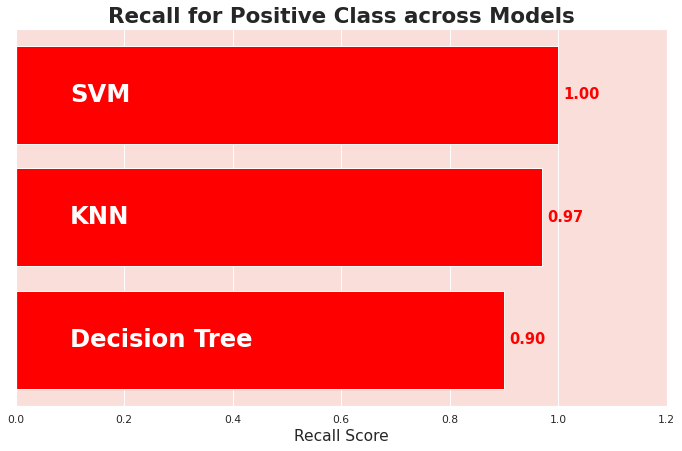

In [55]:
# Sort values based on 'recall_1'
results.sort_values(by='recall_1', ascending=True, inplace=True)
recall_1_scores = results['recall_1']

# Plot the horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 7), dpi=70)
ax.barh(results.index, recall_1_scores, color='red')

# Annotate the values and indexes
for i, (value, name) in enumerate(zip(recall_1_scores, results.index)):
    ax.text(value + 0.01, i, f"{value:.2f}", ha='left', va='center',
            fontweight='bold', color='red', fontsize=15)
    ax.text(0.1, i, name, ha='left', va='center',
            fontweight='bold', color='white', fontsize=25)

# Remove yticks
ax.set_yticks([])

# Set x-axis limit
ax.set_xlim([0, 1.2])

# Add title and xlabel
plt.title("Recall for Positive Class across Models", fontweight='bold', fontsize=22)
plt.xlabel("Recall Score", fontsize=16)

plt.show()